In [2]:
from pesummary.io import read
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import configparser
from scipy.stats import norm
from scipy.optimize import curve_fit

def gaussian(x, mu, sigma):
    return norm.pdf(x, mu, sigma)

def get_config_params(config_path, file_index, params, gaussian_fit=False):
    plot_dict = {}
    for param in params:
        plot_dict[param] = []

    for num in file_index:
        config_path_full = config_path + '_' + str(num) + '.ini'
        config_ini = configparser.ConfigParser()
        config_ini.read(config_path_full, encoding='utf-8')
        config_injection = config_ini['injection_parameters']

        for param in params:
            plot_dict[param].append(float(config_injection[param]))

    
    bins = 35
    for param, values in plot_dict.items():
        if gaussian_fit:
            plt.hist(values, bins=bins, density=True, edgecolor='black')
            # Fit the data
            hist, bin_edges = np.histogram(values, bins=bins, range=(10, 1500), density=True)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            popt, pcov = curve_fit(gaussian, bin_centers, hist, p0=[np.mean(values), np.std(values)])
            mu, sigma = popt
            print(f"Mean: {mu}, Standard Deviation: {sigma}")
            # Plot the Gaussian fit
            x = np.linspace(10, 1500, 1000)
            plt.plot(x, gaussian(x, mu, sigma), 'r-', label='Gaussian fit')
            plt.ylabel('probability density')
            plt.legend()
        else:
            plt.hist(values, bins=bins, edgecolor='black')
            plt.ylabel('counts')
            plt.rcParams["font.size"] = 15
            plt.rcParams["axes.axisbelow"] = True
            plt.xlabel(param)
            plt.grid(axis='x')
            # plt.savefig('injection_value_dL_pp_only_Ab1_dL_iota_for_high_snr_1-1000.pdf', bbox_inches="tight", pad_inches=0.05)
            # plt.close()
            plt.show()

/home/hayato.imafuku/research/env/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


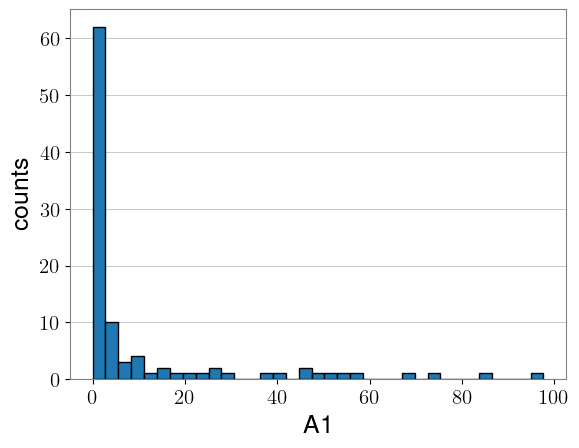

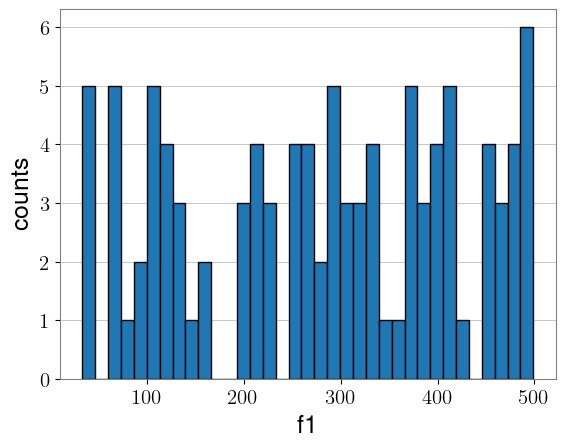

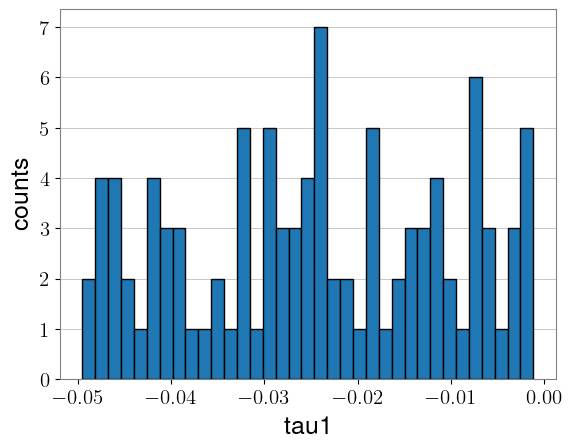

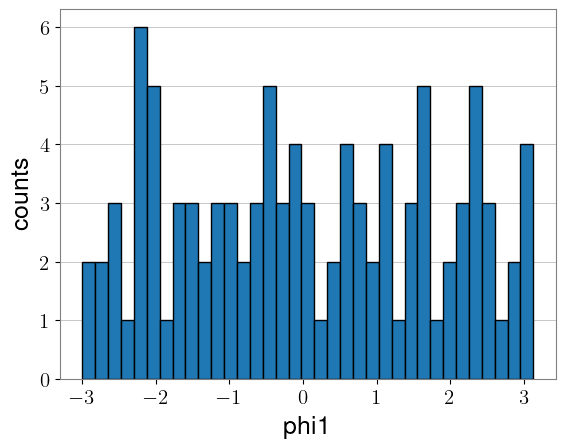

In [ ]:
config_path = './config/pp_one_mode/pp_one_mode'
file_index = np.arange(0, 100, 1)
params = ['A1', 'f1', 'tau1', 'phi1']
get_config_params(config_path, file_index, params)

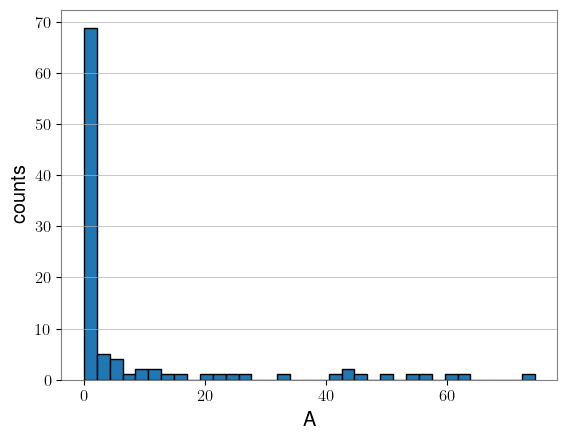

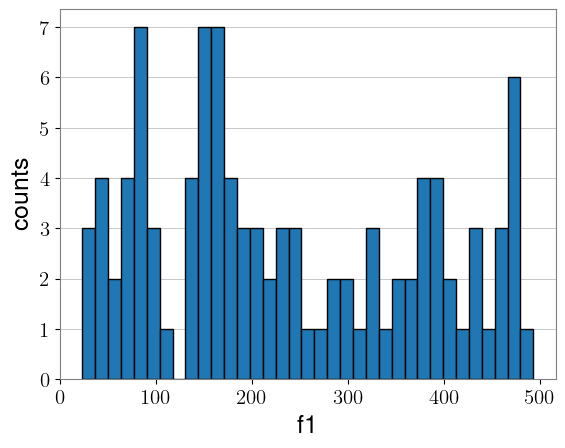

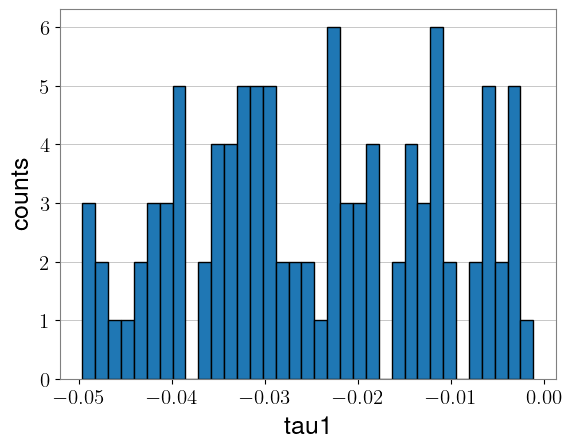

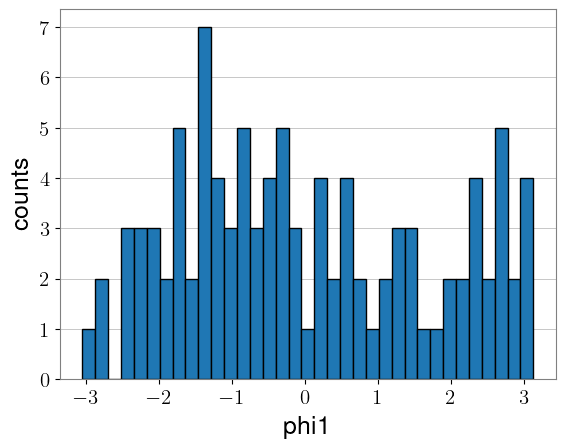

In [4]:
name = 'pp_one_mode_DSPram_APriLogUni'
config_path = './config/{}/{}'.format(name, name)
file_index = np.arange(0, 100, 1)
params = ['A', 'f1', 'tau1', 'phi1']
get_config_params(config_path, file_index, params)